---
jupytext:
  text_representation:
    format_name: myst
kernelspec:
  display_name: Python 3
  language: python
  name: python3
---

# 11. 卵形线 Ovals

卵形线是一类光滑封闭的凸曲线，包括卡西尼卵形线、笛卡尔卵形线等。

In [229]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.unicode_minus'] = False

## 11.1 卡西尼卵形线 Cassini Oval

$(x^2 + y^2 + a^2)^2 - 4a^2x^2 = b^4$

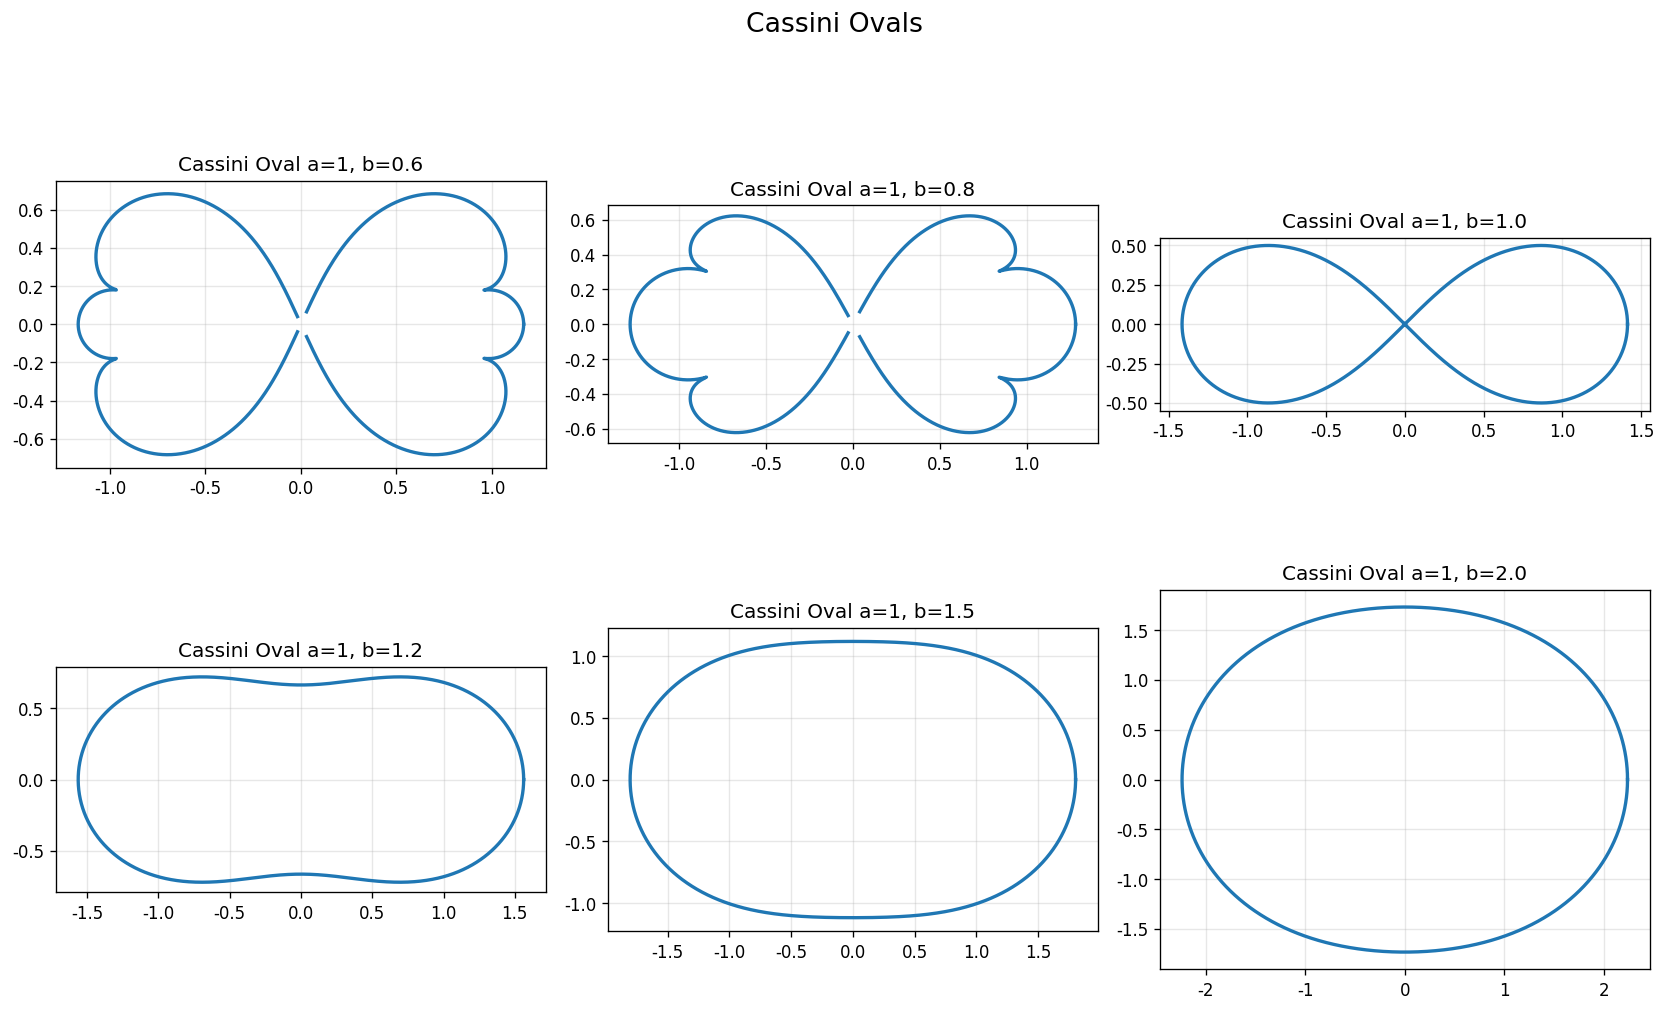

In [230]:
def cassini_oval(a, b, n=3000):
    theta = np.linspace(0, 2*np.pi, n)
    #r2 = a*a*np.cos(2*theta) + np.sqrt(b**4 - a**4*np.sin(2*theta)**2)
    r2 = a*a*np.cos(2*theta) + np.sqrt(np.abs(b**4 - a**4*np.sin(2*theta)**2))
    r = np.where(r2 >= 0, np.sqrt(np.abs(r2)), np.nan)
    return r*np.cos(theta), r*np.sin(theta)

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
a = 1.0
for idx, b in enumerate([0.6, 0.8, 1.0, 1.2, 1.5, 2.0]):
    ax = axes[idx//3][idx%3]
    x, y = cassini_oval(a, b)
    ax.plot(x, y, linewidth=2)
    ax.set_aspect('equal')
    ax.set_title(f'Cassini Oval a=1, b={b}')
    ax.grid(True, alpha=0.3)
plt.suptitle('Cassini Ovals', fontsize=16) # / 卡西尼卵形线
plt.tight_layout()
plt.show()

## 11.2 笛卡尔卵形线 Cartesian Oval

$\\sqrt{(x-a)^2 + y^2} + m\\sqrt{(x+a)^2 + y^2} = d$

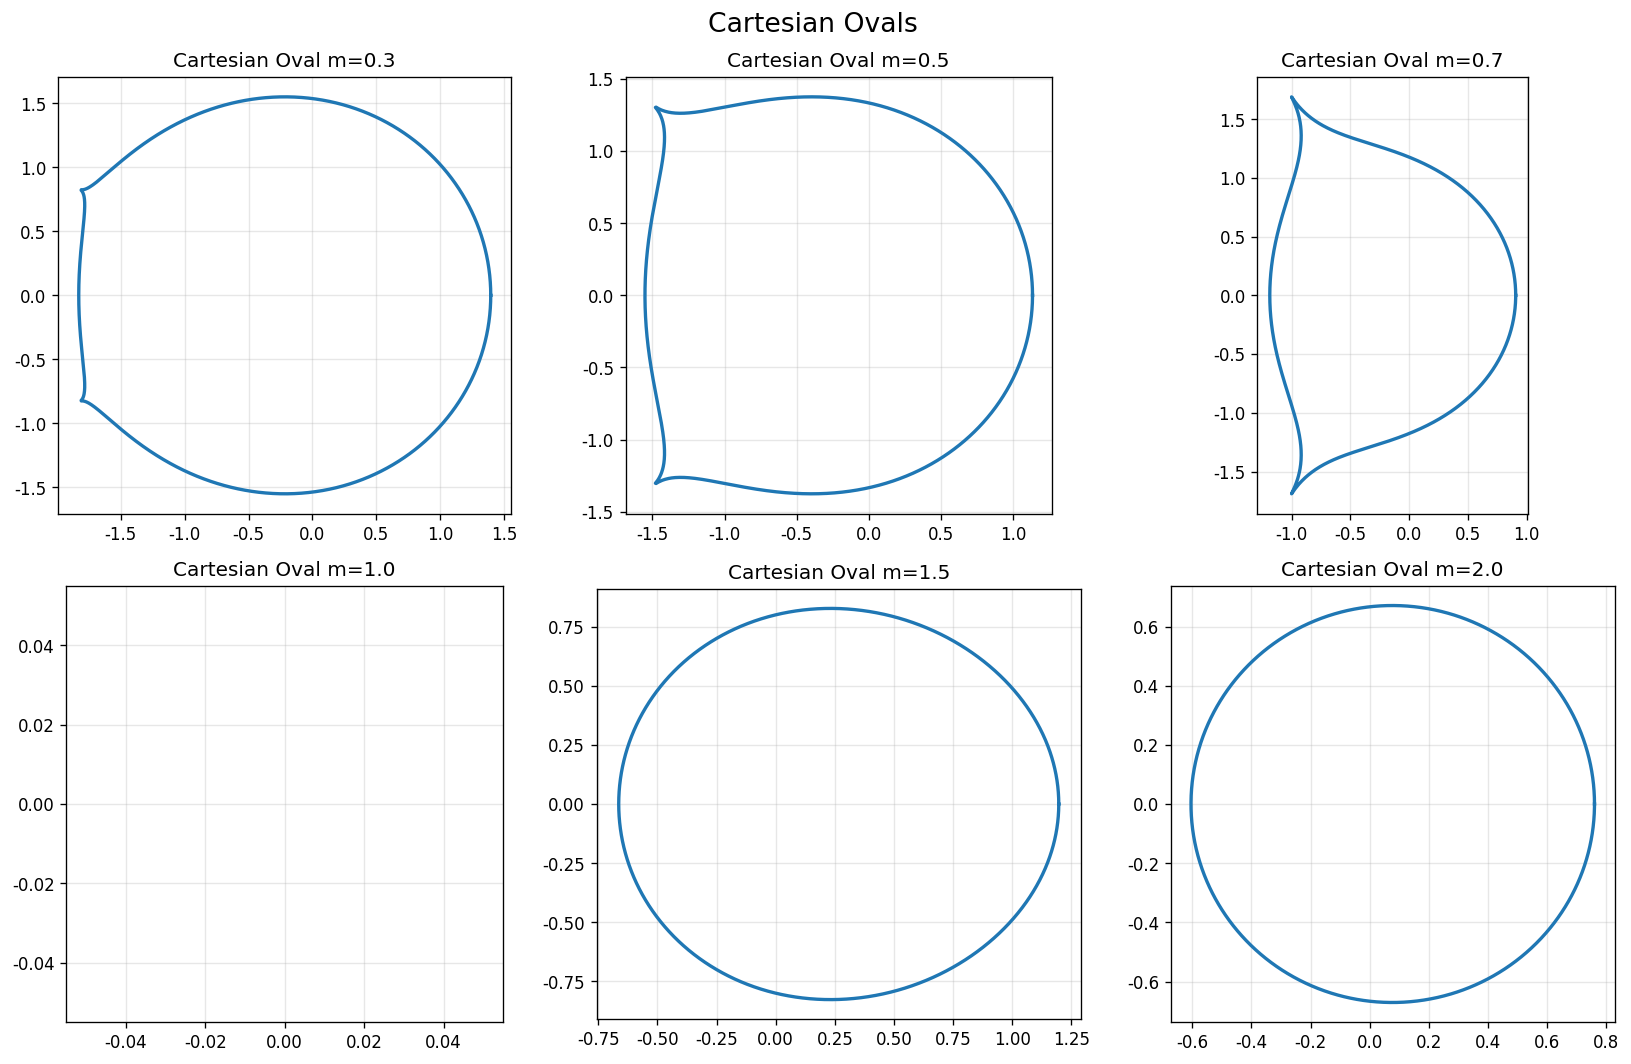

In [231]:
def cartesian_oval(a=1, m=0.5, d=3, n=3000):
    theta = np.linspace(0, 2*np.pi, n)
    cos_t = np.cos(theta)
    #r = d / (1 + m * np.sqrt(1 + 2*a/d * cos_t / (1 - m**2)))
    if m != 1:
        r = d / (1 + m * np.sqrt(np.abs(1 + 2*a/d * cos_t / (1 - m**2))))
        return r*np.cos(theta), r*np.sin(theta)
    else:
        return np.zeros_like(theta), np.zeros_like(theta)

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for idx, m in enumerate([0.3, 0.5, 0.7, 1.0, 1.5, 2.0]):
    ax = axes[idx//3][idx%3]
    x, y = cartesian_oval(1, m, 2)
    ax.plot(x, y, linewidth=2)
    ax.set_aspect('equal')
    ax.set_title(f'Cartesian Oval m={m}')
    ax.grid(True, alpha=0.3)
plt.suptitle('Cartesian Ovals', fontsize=16) # / 笛卡尔卵形线
plt.tight_layout()
plt.show()

## 11.3 椭圆变形 Oval of Booth

$(x^2 + y^2 - ax)^2 = b^2(x^2 + y^2)$

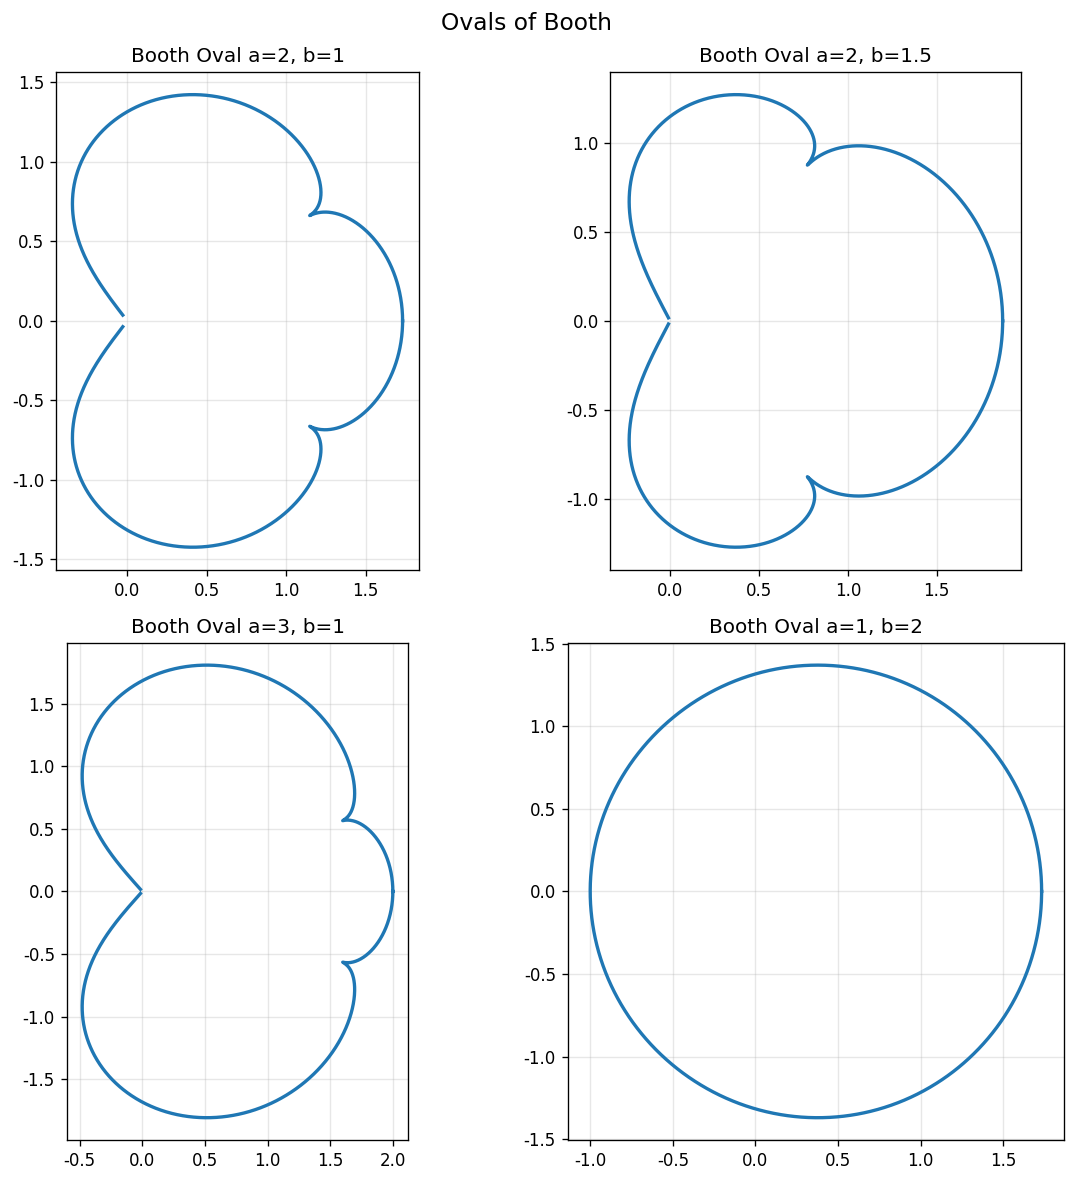

In [232]:
def booth_oval(a=3, b=1, n=3000):
    theta = np.linspace(0, 2*np.pi, n)
    r2 = a*np.cos(theta) + np.sqrt(np.abs(b**2 + a**2*np.cos(theta)**2 - a**2))
    r = np.where(r2 >= 0, np.sqrt(np.abs(r2)), np.nan)
    return r*np.cos(theta), r*np.sin(theta)

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for (a, b), ax in zip([(2,1), (2,1.5), (3,1), (1,2)], axes.flat):
    x, y = booth_oval(a, b)
    ax.plot(x, y, linewidth=2)
    ax.set_aspect('equal')
    ax.set_title(f'Booth Oval a={a}, b={b}')
    ax.grid(True, alpha=0.3)
plt.suptitle('Ovals of Booth', fontsize=14)
plt.tight_layout()
plt.show()

## 11.4 瞳孔线 / 卵圆曲线

$x^4 + y^4 = a^2(x^2 + y^2)$

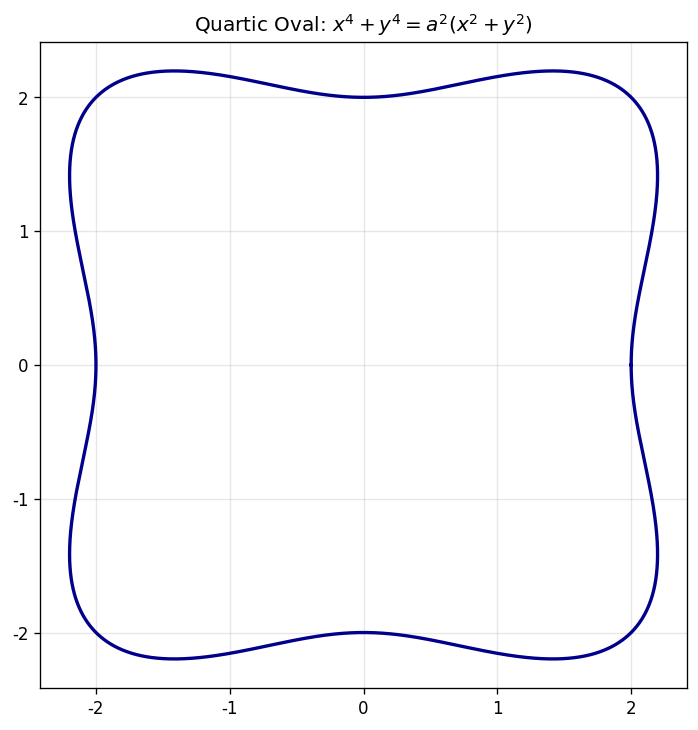

In [233]:
theta = np.linspace(0, 2*np.pi, 3000)
a = 2
r2 = a**2 / (np.sin(theta)**4 + np.cos(theta)**4)
r = np.sqrt(r2)
x, y = r*np.cos(theta), r*np.sin(theta)
fig, ax = plt.subplots(figsize=(7,7))
ax.plot(x, y, 'darkblue', linewidth=2)
ax.set_aspect('equal')
ax.set_title('Quartic Oval: $x^4+y^4=a^2(x^2+y^2)$')
ax.grid(True, alpha=0.3)
plt.show()

## 11.5 蛋形 Egg Shape (Granville's Egg)

$x = (1 + k\\cos t)\\cos t, \quad y = (1 + k\\cos t)\\sin t$

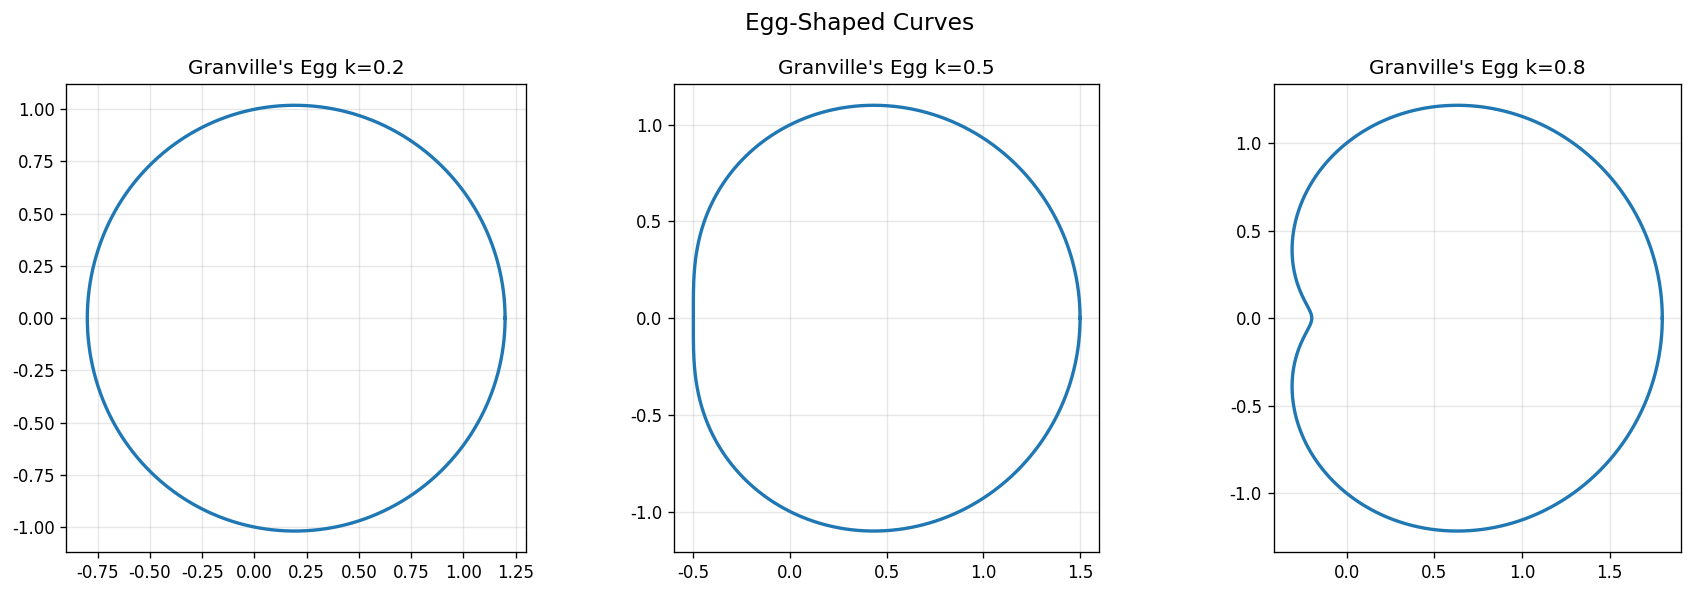

In [234]:
t = np.linspace(0, 2*np.pi, 3000)
fig, axes = plt.subplots(1, 3, figsize=(15,5))
for ax, k in zip(axes, [0.2, 0.5, 0.8]):
    r = 1 + k * np.cos(t)
    x, y = r*np.cos(t), r*np.sin(t)
    ax.plot(x, y, linewidth=2)
    ax.set_aspect('equal')
    ax.set_title(f"Granville's Egg k={k}")
    ax.grid(True, alpha=0.3)
plt.suptitle('Egg-Shaped Curves', fontsize=14)
plt.tight_layout()
plt.show()

## 11.6 苔藓形 / 莫斯蛋 Moss's Egg

极坐标中的蛋形曲线。

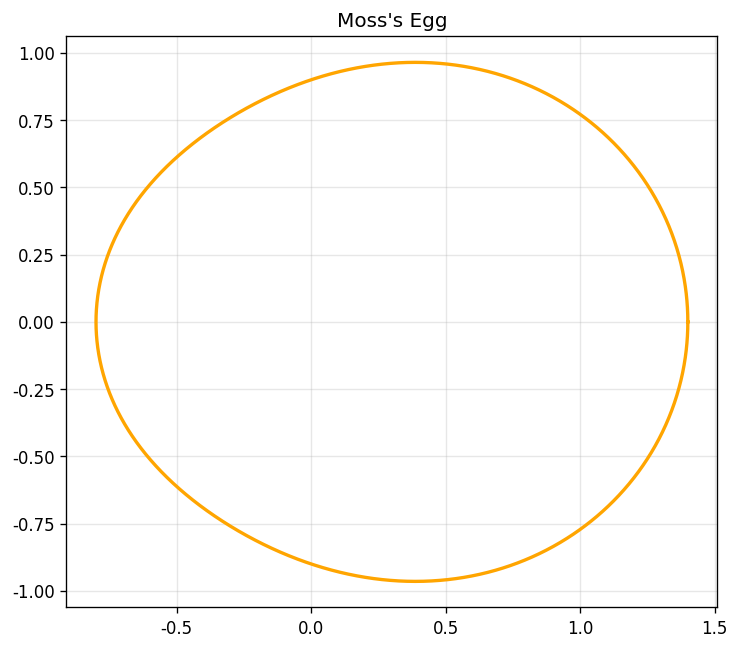

In [235]:
t = np.linspace(0, 2*np.pi, 3000)
r = 1 + 0.3*np.cos(t) + 0.1*np.cos(2*t)
x, y = r*np.cos(t), r*np.sin(t)
fig, ax = plt.subplots(figsize=(7,7))
ax.plot(x, y, 'orange', linewidth=2)
ax.set_aspect('equal')
ax.set_title("Moss's Egg") # / 莫斯蛋形
ax.grid(True, alpha=0.3)
plt.show()

## 11.7 弹道卵形 Ballistic Oval

类似弹道轨迹的卵形曲线。

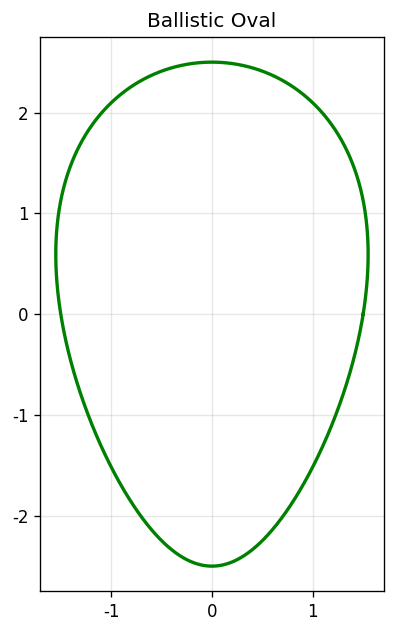

In [236]:
t = np.linspace(0, 2*np.pi, 3000)
a, b = 1.5, 2.5
x = a * np.cos(t) + 0.2 * np.sin(2*t)
y = b * np.sin(t)
fig, ax = plt.subplots(figsize=(8,6))
ax.plot(x, y, 'green', linewidth=2)
ax.set_aspect('equal')
ax.set_title('Ballistic Oval') # / 弹道卵形
ax.grid(True, alpha=0.3)
plt.show()

## 11.8 美式足球曲线 Football Curve

$x = \\cos t + \\cos^{3}t, \quad y = \\sin t$

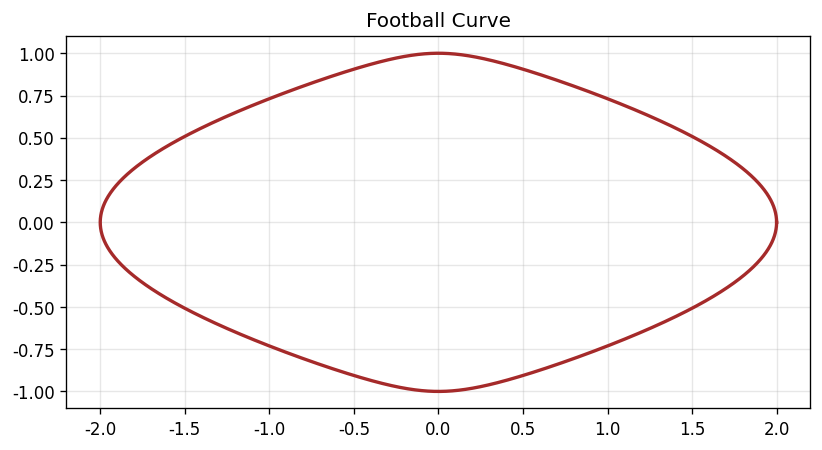

In [237]:
t = np.linspace(0, 2*np.pi, 3000)
x = np.cos(t) + np.cos(t)**3
y = np.sin(t)
fig, ax = plt.subplots(figsize=(8,6))
ax.plot(x, y, 'brown', linewidth=2)
ax.set_aspect('equal')
ax.set_title('Football Curve') # / 美式足球曲线
ax.grid(True, alpha=0.3)
plt.show()

## 11.9 仿卵线 Ovoid

$r = \\frac{1}{1 + e\\cos\\theta}$ 偏心版。

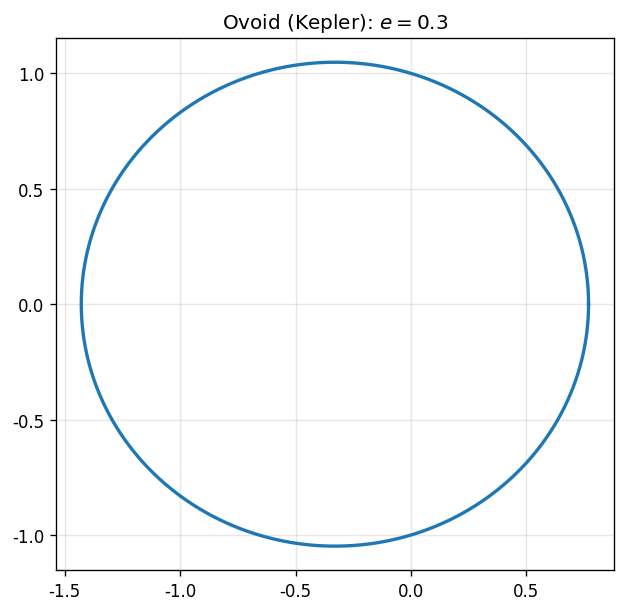

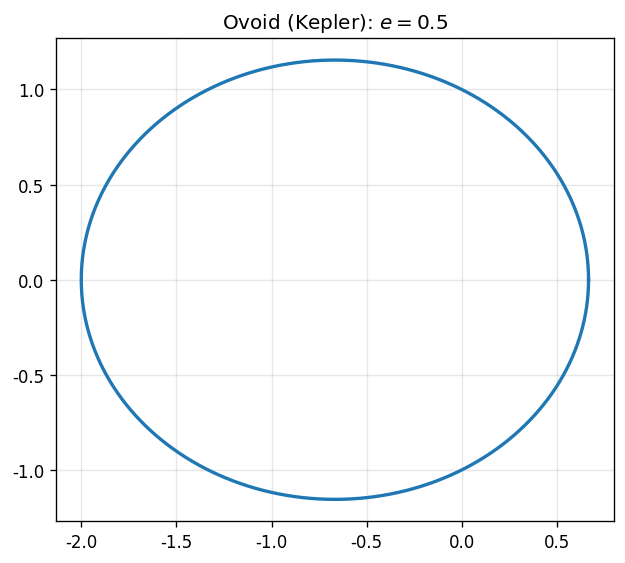

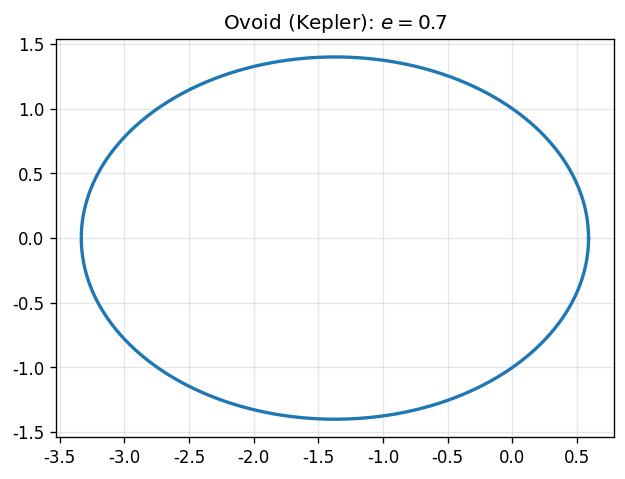

In [238]:
t = np.linspace(0, 2*np.pi, 3000)
for e in [0.3, 0.5, 0.7]:
    r = 1 / (1 + e * np.cos(t))
    x, y = r*np.cos(t), r*np.sin(t)
    fig, ax = plt.subplots(figsize=(6,6))
    ax.plot(x, y, linewidth=2)
    ax.set_aspect('equal')
    ax.set_title(f'Ovoid (Kepler): $e={e}$')
    ax.grid(True, alpha=0.3)
    plt.show()

## 11.10 卵形线总览 Oval Overview

各种卵形线对比面板。

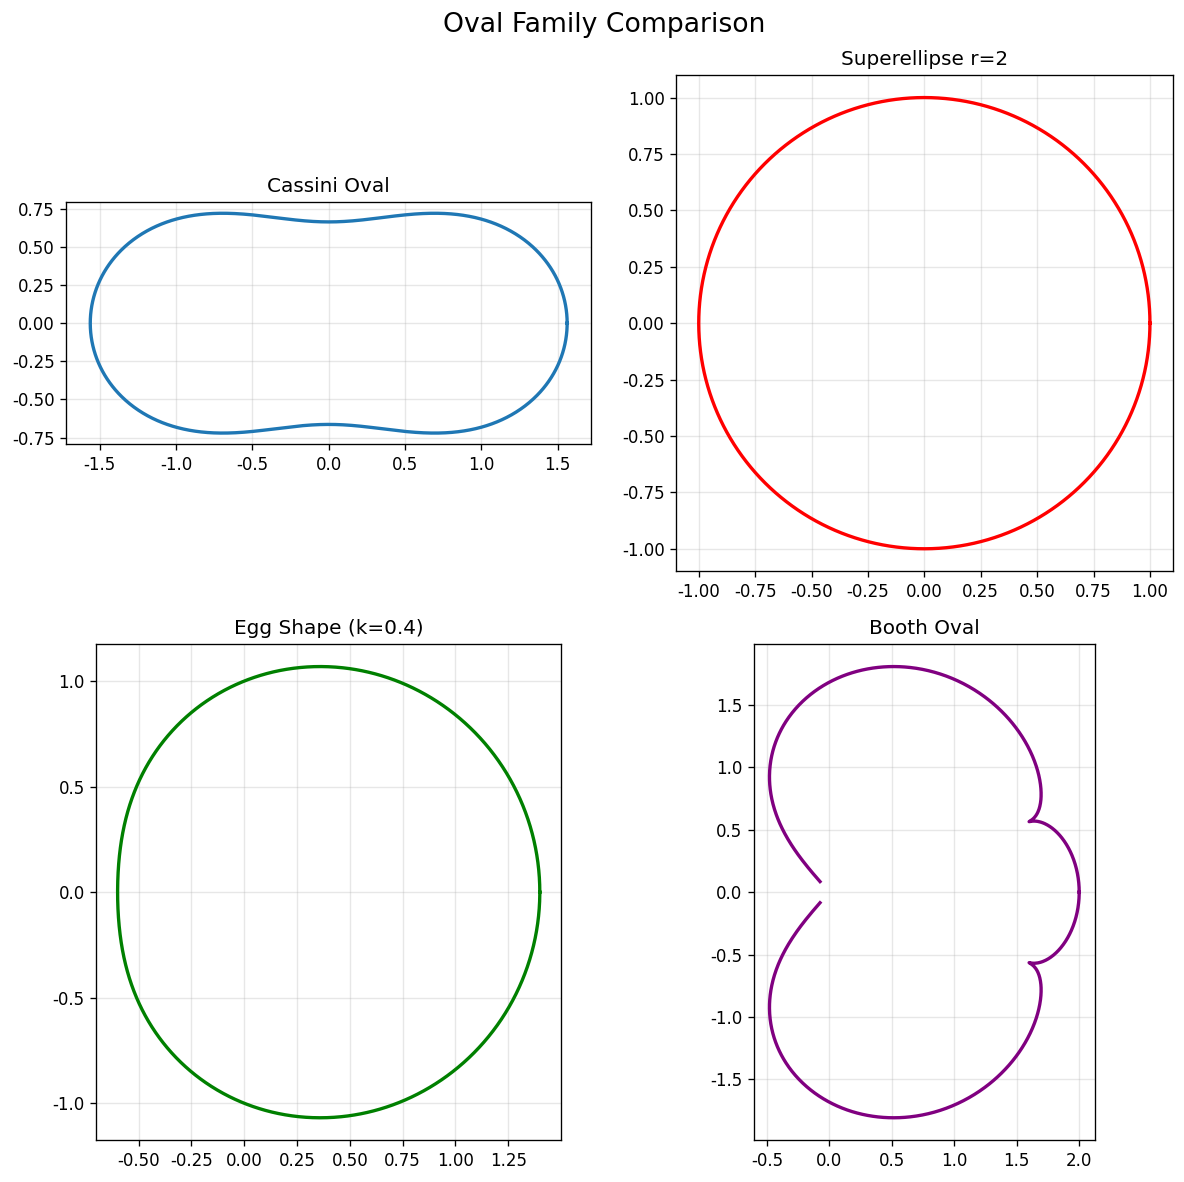

In [239]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# Cassini (b=1.2)
t = np.linspace(0, 2*np.pi, 2000)
r2 = 1*np.cos(2*t) + np.sqrt(1.2**4 - np.sin(2*t)**2)
r = np.where(r2>=0, np.sqrt(np.abs(r2)), np.nan)
axes[0,0].plot(r*np.cos(t), r*np.sin(t), linewidth=2)
axes[0,0].set_title('Cassini Oval'); axes[0,0].set_aspect('equal')
axes[0,0].grid(True, alpha=0.3)

# Superellipse
r_param = 2.0
x = np.sign(np.cos(t))*np.abs(np.cos(t))**(2/r_param)
y = np.sign(np.sin(t))*np.abs(np.sin(t))**(2/r_param)
axes[0,1].plot(x, y, 'r-', linewidth=2)
axes[0,1].set_title('Superellipse r=2'); axes[0,1].set_aspect('equal')
axes[0,1].grid(True, alpha=0.3)

# Egg
r_egg = 1 + 0.4*np.cos(t)
axes[1,0].plot(r_egg*np.cos(t), r_egg*np.sin(t), 'g-', linewidth=2)
axes[1,0].set_title('Egg Shape (k=0.4)'); axes[1,0].set_aspect('equal')
axes[1,0].grid(True, alpha=0.3)

# Booth Oval
r2_b = 3*np.cos(t) + np.sqrt(np.abs(1**2 + 9*np.cos(t)**2 - 9))
r_b = np.where(r2_b>=0, np.sqrt(np.abs(r2_b)), np.nan)
axes[1,1].plot(r_b*np.cos(t), r_b*np.sin(t), 'purple', linewidth=2)
axes[1,1].set_title('Booth Oval'); axes[1,1].set_aspect('equal')
axes[1,1].grid(True, alpha=0.3)

plt.suptitle('Oval Family Comparison', fontsize=16)
plt.tight_layout()
plt.show()